# COMP1008 2024/25 Coursework - Wine Quality Prediction with Machine Learning

#### **Student Name**: Curtis Millership
#### **Student ID**: psycm12

## Task description

**Main Task**: Utilizing the provided Red Wine Quality dataset, build a Linear Regression Model and another Machine Learning Model of your choice to predict wine quality. Employ appropriate methods from the `pandas`, `matplotlib`, and `sklearn` libraries to analyze and process the dataset for building predictive models.



**Format**: Use this Jupyter Notebook as a template to write your report in `Markdown` cells, supported by your source code in Code cells. Ensure your code produces the corresponding plots or results addressing the questions. Rename this .ipynb file to `202425_COMP1008_cw_XXX.ipynb`, where XXX is your username (e.g., psxyz), and submit it to Moodle by <b><font color = "red">24 March, 3pm</font></b>.

**Marks**: The coursework is worth a total of 100 marks (accounting for 25% of the COMP1008 module grade). Marks will be awarded based on your understanding of machine learning theories, the informativeness and presentation of your code, visualizations, results (e.g., code comments, necessary labels in plots), self-learning ability in solving the specific problem, as well as, how succinct, concise, and clear is your report writing.

Please check the detailed instructions at the end of this template file.

<div class="alert alert-success" style="text-align:left;">
<h2>Question 1. Prediction Model 1 - Linear Regression Model<span style="float:right;">[50 marks]</span></h2></div>

#### Question 1a <span style="color:red">(5 marks)</span> 
**TASK**: Briefly explain why the Red Wine Quality dataset is suitable for linear regression analysis.
- Identify at least 3 characteristics that make this dataset appropriate for regression.
- Use 3 bullet points (one for each characteristics) to present your answer concisely.
- Your explanation should reflect your understanding of the linear regression model.

<b>Q1a Answer</b>: Your answer here

In [31]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error





---

#### Question 1b <span style="color:red">(15 marks)</span>

**TASK**: Analyze the dataset using appropriate methods from the `pandas` and/or `matplotlib` libraries. 
- Identify potential issues with the current dataset, specify which part(s) of the dataset are affected. Explain what could go wrong if the data is not properly pre-processed.
- Provide at least 2 short-code solutions demonstrating how you analyze these issues.  
- Briefly explain how each code snippet helps evaluate data quality issues.


Missing values per feature:
fixed acidity             0
volatile acidity          0
citric acid               0
residual sugar            0
chlorides                 0
free sulfur dioxide     187
total sulfur dioxide      0
density                  91
pH                       19
sulphates                 0
alcohol                   0
quality                   0
dtype: int64 

Amount of outliers per feature:
fixed acidity            49
volatile acidity         19
citric acid               1
residual sugar          155
chlorides               112
free sulfur dioxide      25
total sulfur dioxide     55
density                  45
pH                       34
sulphates                59
alcohol                  18
quality                  13
dtype: int64


---

#### Question 1c <span style="color:red">(20 marks)</span>
**TASK**: Apply appropriate data preprocessing techniques to address the issues identified in Question 1b.
- Provide a code solution that resolves the identified data issue(s).
- Briefly explain the methods and parameters used in your solution. Ensure your explanation clearly justifies how these techniques improve data quality and suitability for analysis.


<b>Q1c answer</b>: 

In [37]:
preprocessed_dataset = pd.read_csv(
    r"C:\Users\curti\Desktop\AI Coursework\CourseWork 202425\winequality-red.csv"
)

# Removes all rows with a missing value.
no_missing_val_dataset = preprocessed_dataset.dropna()

# Calculates the first and third quartiles from the dataset without missing values.
first_quartile = no_missing_val_dataset.quantile(
    0.25
)  # First quartile (25th percentile)
third_quartile = no_missing_val_dataset.quantile(
    0.75
)  # Third quartile (75th percentile)

# Calculates the interquartile range by subtracting the first quartile from the third quartile.
interquartile_range = third_quartile - first_quartile

# Finds outliers using the interquartile range method.
outliers = (
    no_missing_val_dataset < (first_quartile - 1.5 * interquartile_range)
) | (no_missing_val_dataset > (third_quartile + 1.5 * interquartile_range))

# Filter out rows with outliers.
cleaned_dataset = no_missing_val_dataset[~outliers.any(axis=1)]

# The missing values have been filtered out using dropna(), as missing values can lead to biased or incomplete results.
# Outliers have been removed using the interquartile range method, as extreme values can disproportionately influence the mean or variance, leading to skewed results.



---

#### Question 1d <span style="color:red">(10 marks)</span>

**TASK**: Train and evaluate a Linear Regression model using the preprocessed dataset.   
- Print the model's weights.  
- Print the model's accuracy. 
    - Evaluate the model using at least three different metrics.
    - Briefly discuss the advantages of each metric in assessing model performance.


<b>Q1d answer</b>: 

Coefficients (sorted by feature importance):
density: -50.6691
sulphates: 1.6748
volatile acidity: -1.0144
chlorides: -0.8801
pH: -0.6353
citric acid: -0.4807
alcohol: 0.2135
residual sugar: 0.0651
fixed acidity: 0.0569
total sulfur dioxide: -0.0032
free sulfur dioxide: 0.0031

R-squared score:
 0.3228327983049004 

Mean Squared Error:
 0.46310066780679854 

Mean Absolute Error:
 0.5398302439416114 



---

<div class="alert alert-success" style="text-align:left;"><h2>Question 2. Prediction Model 2<span style="float:right;">[20 marks]</span></h2></div>

#### Question 2a <span style="color:red">(10 marks)</span>

**TASK**: Build a different machine learning model for the same prediction task.
- Choose a model covered in the lectures or explain your choice of a different method. If you choose a different method, provide at at least two arguments to justify your choice compared to the ones covered in the lectures. 
- Specify which model you selected and why. 
- List the key parameters of your chosen model (Model 2).
- Provide a code implementation for the selected method.

<b>Q2a answer</b>: 

In [112]:
X = cleaned_dataset.drop("quality", axis=1)
Y = cleaned_dataset["quality"]

# Splits the data into 80% training and 20% testing. random_state ensures the same sample is used for training and testing each time the code is run.
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Initialises polynomial regression model. Degree=2 means the model creates new polynomial features by squaring the original features.
# include_bias=False means an extra column full of ones is not added to the data.
# The extra column of ones is sometimes added because it shifts the origin, which can create a better fit for datasets where the relationship
# doesn’t pass through the origin or to compensate for bias in certain situations.
# We don't need this as it adds extra complexity and would force the model to focus on the intercept
# when the relationship is already being captured using polynomial features.
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(
    X_train
)  # Transforms the training data in X_train into polynomial features

X_test_poly = poly.transform(
    X_test
)  # Transforms the test data in X_test into polynomial features.

model = (
    LinearRegression()
)  # Trains the linear regression model using polynomial features and the targets in Y_train.
model.fit(X_train_poly, Y_train)

Y_pred = model.predict(X_test_poly)  # Make predictions using X_test_poly

# Measure model performance using R-Squared, Mean Squared Error and Mean Absolute Error
r2 = r2_score(Y_test, quality_prediction)
print("\nR-squared score:\n", r2, "\n")

mse = mean_squared_error(Y_test, quality_prediction)
print("Mean Squared Error:\n", mse, "\n")

mae = mean_absolute_error(Y_test, quality_prediction)
print("Mean Absolute Error:\n", mae, "\n")

# Display coefficients with feature names and order by feature importance
feature_importance = pd.Series(
    model.coef_, index=poly.get_feature_names_out(X.columns)
)
feature_importance = feature_importance.reindex(
    feature_importance.abs().sort_values(ascending=False).index
)

print("\ncoefficients (sorted by feature importance):")
for name, coef in feature_importance.items():
    print(f"{name}: {coef:.4f}")

# Polynomial regression captures non-linear relationships, such as wine quality being adversely affected by alcohol level,
# where an extremely high amount of alcohol could actually cause an inverse relationship.
# Polynomial regression displays this by squaring the features, such as alcohol.

# Polynomial regression can also help understand how features interact to affect the target. 
# For example a high alcohol drink containing more sugar to improve the taste.
# If the model showed a positive relationship between alcohol, sugar and quality 
# this could mean more sugar in a high alcohol drink could improve quality.



R-squared score:
 0.3228327983049004 

Mean Squared Error:
 0.46310066780679854 

Mean Absolute Error:
 0.5398302439416114 


coefficients (sorted by feature importance):
density: -48742.6182
density^2: 24811.5797
density sulphates: -592.9464
sulphates: 556.7856
chlorides density: -426.3295
chlorides: 366.0326
volatile acidity density: -301.2297
volatile acidity: 284.3841
pH: 253.0554
density pH: -222.2509
citric acid: 130.1793
citric acid density: -129.8598
residual sugar density: -71.3115
residual sugar: 69.5978
density alcohol: 48.3843
alcohol: -47.6874
chlorides sulphates: 15.9534
volatile acidity chlorides: 10.4339
pH sulphates: 9.8431
free sulfur dioxide: -6.9019
fixed acidity density: 6.7059
free sulfur dioxide density: 6.6863
pH^2: -4.9587
fixed acidity: -3.8227
volatile acidity pH: 3.6544
volatile acidity citric acid: 3.4166
volatile acidity sulphates: -3.3962
chlorides pH: 3.1296
sulphates^2: -2.8264
chlorides^2: 2.5282
residual sugar chlorides: -2.2403
chlorides alcohol: 2.

---

### Question 2b <span style="color:red">(10 marks)</span>
**TASK**: Evaluate the performance of your new model and compare it to Prediction Model 1.
- Analyze whether the new model performs better or worse and explain why.
    - Base your evaluation on the same metrics used in Question 1d).
- Include one plot visually comparing the performance of both models.
- Provide a brief textual explanation interpreting the results.

<b>Q2b answer</b>: 

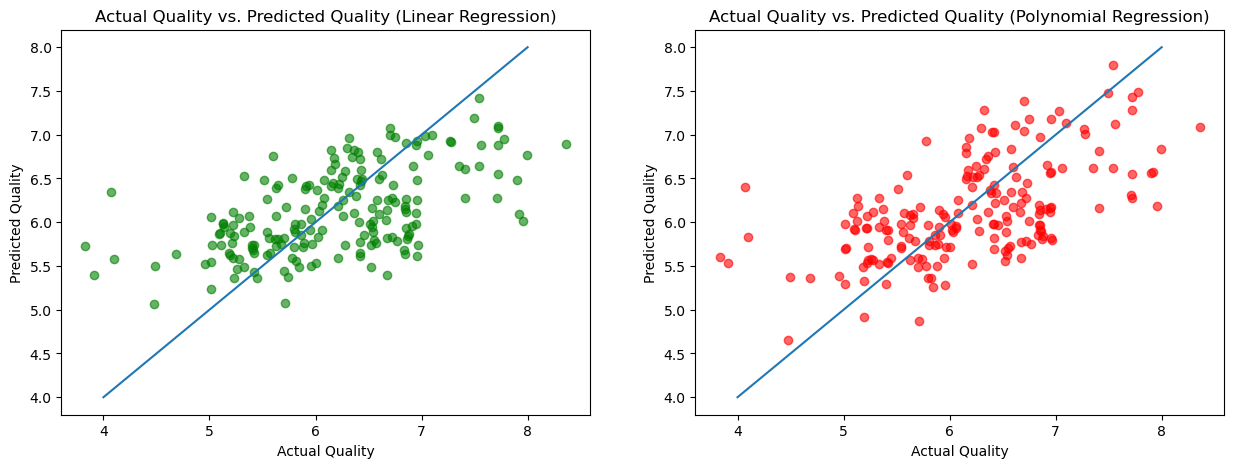

In [113]:
models = [
    (quality_prediction, "Linear Regression"),
    (Y_pred, "Polynomial Regression"),
]

plt.figure(figsize=(15, 5))
colors = ["green", "red"]

for i, (pred, model_name) in enumerate(models, 1):
    plt.subplot(1, 2, i)
    plt.scatter(Y_test, pred, alpha=0.6, color=colors[i - 1])
    plt.plot([4, 8], [4, 8])
    plt.xlabel("Actual Quality")
    plt.ylabel("Predicted Quality")
    plt.title(f"Actual Quality vs. Predicted Quality ({model_name})")

plt.show()

# The accuracy of the polynomial regression model and linear regression model are identical in this situation.
# The R2, MSE and MAE scores are the exact same for each.
# This means the polynomial regression model did not identify any additional non-linear relationships.
# It also suggests the dataset does not contain any notable relationships between features, which could reveal how combinations of features affect the target.

# Neither model looks good enough to predict wine quality precisely. The R2 scores of 0.32 make this clear.
# Increasing the polynomial degree could cause overfitting.
# It may be best to attempt a non-linear model, such as random forest.




---

<div class="alert alert-success" style="text-align:left;"><h2>Question 3. Comparison and Improvement<span style="float:right;">[30 marks]</span></h2></div>

#### Question 3a <span style="color:red">(15 marks)</span>
**TASK**: Analyze the impact of removing the least important feature from Prediction Model 1.
- Identify and remove the least important feature. 
- Retrain the Linear Regression model and evaluate its performance. 
- Compare the results before and after feature removal.
- Provide a code implementation and a justification explaining the impact on model performance.


<b>Q3a answer</b>:

In [114]:
least_important_feature = coefficients.abs().idxmin()
print(f"Least Important Feature:\n{least_important_feature}")

X_rm_LIF = X.drop(least_important_feature, axis=1)
X_train_rm_LIF, X_test_rm_LIF, Y_train, Y_test = train_test_split(
    X_rm_LIF, Y, test_size=0.2, random_state=42
)

LR_model_rm_LIF = LinearRegression()
LR_model_rm_LIF.fit(X_train_rm_LIF, Y_train)
quality_pred_rm_LIF = LR_model_rm_LIF.predict(X_test_rm_LIF)

r2_rm_LIF = r2_score(Y_test, quality_pred_rm_LIF)
mse_rm_LIF = mean_squared_error(Y_test, quality_pred_rm_LIF)
mae_rm_LIF = mean_absolute_error(Y_test, quality_pred_rm_LIF)

print("\nOriginal:")
print(f"R^2: {r2}")
print(f"MSE: {mse}")
print(f"MAE: {mae}\n")

print("After Least Important Feature Removed:")
print(f"R^2: {r2_rm_LIF}")
print(f"MSE: {mse_rm_LIF}")
print(f"MAE: {mae_rm_LIF}")

# Removing the least important feature made very little difference to the accuracy scores and increases model efficiency.
# This improves the speed of the program and can reduce the risk of overfitting.
# More features could potentially be removed.

Least Important Feature:
free sulfur dioxide

Original:
R^2: 0.3228327983049004
MSE: 0.46310066780679854
MAE: 0.5398302439416114

After Least Important Feature Removed:
R^2: 0.3212640974055456
MSE: 0.4641734699629895
MAE: 0.5391433610899528


---

#### Question 3b <span style="color:red">(15 marks)</span>
**TASK**: Based on your observations, suggest strategies for improving future models when predicting on new data.
- Discuss potential improvements. 

<b>Hint</b>: based on relevant analysis, feature selection, feature scaling and data processing (e.g. resolve imbalanced samples, errors and outliers, etc.) could all potentially improve the model by reducing training time, fixing overfitting and improving interpretability, etc. 
You can also explore external resources for other potential approaches or techniques.<br>

<b>Note</b>: Coding is optional here, but your answers should be supported by relevant analysis or justifications.

<b>Q3b answer</b>:

In [ ]:
# Selecting another model such as random forest to find non-linear relationships. 
# Random forest is also less prone to overfitting, though this wasn't a problem in this instance.
# It is also possible to stack models which can increase accuracy.
# Implementing Recursive Feature Elimination would automatically remove the least important features.
# It is possible to remove low variance features using: 
from sklearn.feature_selection import VarianceThreshold
# Fewer features improves the model's speed.



---

## Appendix. Coursework Instructions

<b>Coursework Support</b>:
- COMP1008 computing tutorials and exercises on data processing and machine learning models on different example problems
- Example code building and analysing machine learning models in COMP1008 lectures slides on 'Machine learning'
- In the computing sessions, Q&A support for developing .ipynb projects
- In Teams channel 'COMP1008 2024/25 / Questions': support of common questions

<b>Marks</b>: in total 100 marks (count for 25% in COMP1008), awarded on the basis of:
- knowledge and understanding on the theories covered in lectures when answering the questions in the Jupyter Notebook report
- how informative and well presented your code, visualisations and results are (e.g. necessary labels in plots)
- self-learning ability making use of tutorial materials and online resources
- problem solving skills to obtain the answers and results for the specific dataset
- concise report with key details, e.g. parameters, data, etc. for others to repeat your methods and obtain the same results.

For more information of COMP1008 assessment please refer to the coursework issue in Moodle ('Course Content / Assessment').

<b>Format</b>:
- One single .ipynb file named 202425_COMP1008_cw_XXX.ipynb, where XXX is your username (e.g. psxyz)
- The .ipynb file should include your code and answers, using this given .ipynb template (please add cells as needed)
- You could use additional Python libraries as you wish, in addition to the ones demonstrated in the computing sessions
- There are multiple ways using different methods to complete the tasks. These are fine as long as all answers and analysis are supported by the code implemented in Jupyter Notebook, not by using other means (e.g. operations in Excel, or by using other languages, etc.).

<b>Submission</b>: 
- Deadline: <b><font color = "red">24 March, 3pm</font></b>.
- Late submission leads to a 5% deduction of the coursework on each weekday. Work submitted one week late will receive a 0 for the coursework.
- Method: in Moodle submit a single .ipynb file named 202425_COMP1008_cw_XXX.ipynb
- If you can’t submit your coursework on time due to ECs, please contact Student Services and your personal tutor ASAP

<b>Note: Plagiarism vs. Group Discussions</b> 

As you should know, plagiarism is completely unacceptable and will be dealt with according to University's standard policies.<br>
Students are encouraged to have only general discussions on the theory (not the specific questions) when completing the coursework.<br>
It is important that when you actually do your coursework and write the answers, you do it individually.<br>
Do NOT, under any circumstances, share your report, code or figures, etc. with anyone else.